<a href="https://www.kaggle.com/code/abeeralzebda/adult-income-prediction?scriptVersionId=319748682" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/wenruliu/adult-income-dataset/adult.csv


# Adult income prediction 
- By : ABeer Al-Zebda | Machine learning Engineer

## Load and inspect data

In [2]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv('/kaggle/input/datasets/wenruliu/adult-income-dataset/adult.csv')
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


## Explore data

In [5]:
df.isna( ).sum()

age                0
workclass          0
fnlwgt             0
education          0
educational-num    0
marital-status     0
occupation         0
relationship       0
race               0
gender             0
capital-gain       0
capital-loss       0
hours-per-week     0
native-country     0
income             0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(52)

I won't delete the duplicates cause it may represnt diffirent adults

## Exploratory Visualizations

Text(0, 0.5, ' educational-num')

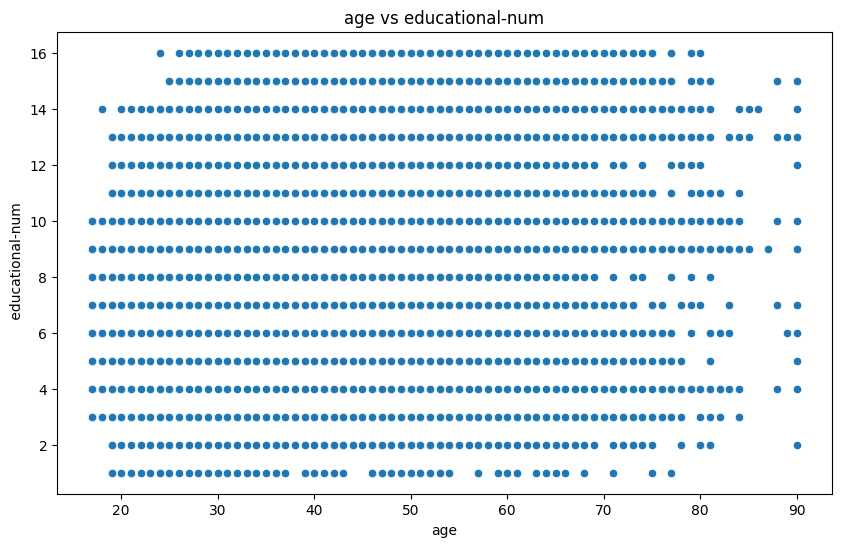

In [7]:
fig,ax=plt.subplots(figsize=(10,6))
sns.scatterplot(data=df , x='age',y='educational-num')
ax.set_title('age vs educational-num')
ax.set_xlabel('age')
ax.set_ylabel(' educational-num')

No relationship 

Text(0, 0.5, 'hours-per-week')

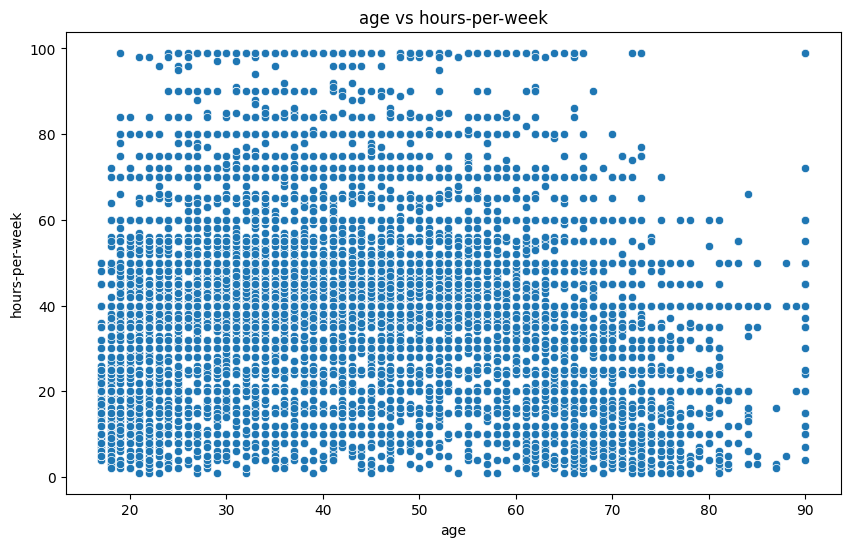

In [8]:

fig,ax=plt.subplots(figsize=(10,6))
sns.scatterplot(data=df , x='age',y='hours-per-week')
ax.set_title('age vs hours-per-week')
ax.set_xlabel('age')
ax.set_ylabel('hours-per-week')

<Axes: xlabel='income', ylabel='age'>

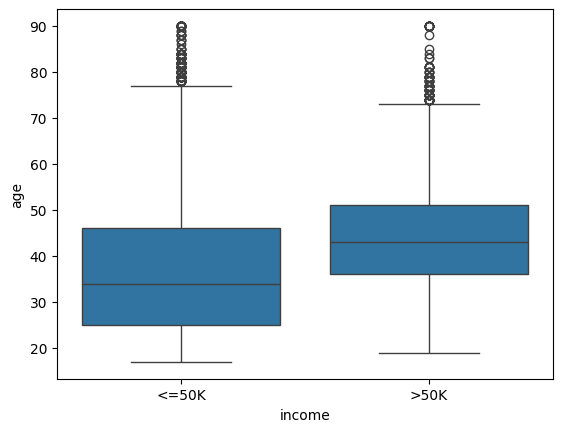

In [9]:
sns.boxplot(data=df , x='income',y='age')

the adults that have income more than 50K are bigger 

<Axes: xlabel='income', ylabel='hours-per-week'>

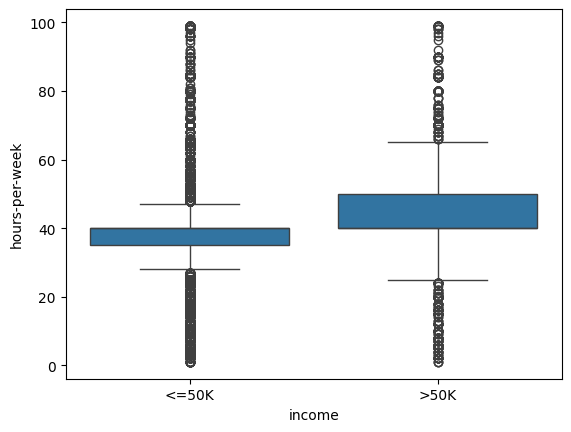

In [10]:
sns.boxplot(data=df , x='income',y='hours-per-week')

## Preprocess data

In [11]:
X = df.drop(columns=["income"])
y = df['income']

In [12]:
# train_test_split is used to divide the data into training and testing sets
from sklearn.model_selection import train_test_split

# StandardScaler is used to standardize the features
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
num_cols = X_train. select_dtypes("number").columns
print("Numeric Columns:", num_cols)
# instantiate preprocessors
scaler = StandardScaler()
# Make a numeric preprocessing pipeline
num_pipe = make_pipeline( scaler)
num_tuple = ('numeric',num_pipe,num_cols)

#####

ohe_cols = X_train.select_dtypes('object').columns
print("OneHotEncoder Columns:", ohe_cols)
# Instantiate the individual preprocessors
ohe_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
# Make pipeline with imputer and encoder
ohe_pipe = make_pipeline(ohe_encoder)
ohe_tuple = ('categorical', ohe_pipe, ohe_cols)

#####
preprocessor= ColumnTransformer([num_tuple, ohe_tuple],
verbose_feature_names_out=False)
preprocessor

Numeric Columns: Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')
OneHotEncoder Columns: Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object')


ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('standardscaler',
                                                  StandardScaler())]),
                                 Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                ('categorical',
                                 Pipeline(steps=[('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))],
                  verbose_feature_names_out=False)

## Build Model

In [15]:
from sklearn.ensemble import RandomForestClassifier
rf_clf = RandomForestClassifier(random_state = 42)
pipe= make_pipeline(preprocessor,rf_clf)
pipe.fit(X_train,y_train)

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('standardscaler',
                                                                   StandardScaler())]),
                                                  Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')),
                                                 ('categorical',
                                                  Pipeline(steps=[('onehotencoder',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country'],
      dtype='object'))],
                                   verbose_feature_names_out=False)),
                ('randomforestclassifier',
                 RandomForestClassifier(random_state=42))])

In [16]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
y_pred = pipe.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[6929  550]
 [ 817 1473]]
              precision    recall  f1-score   support

       <=50K       0.89      0.93      0.91      7479
        >50K       0.73      0.64      0.68      2290

    accuracy                           0.86      9769
   macro avg       0.81      0.78      0.80      9769
weighted avg       0.86      0.86      0.86      9769



## feature importance

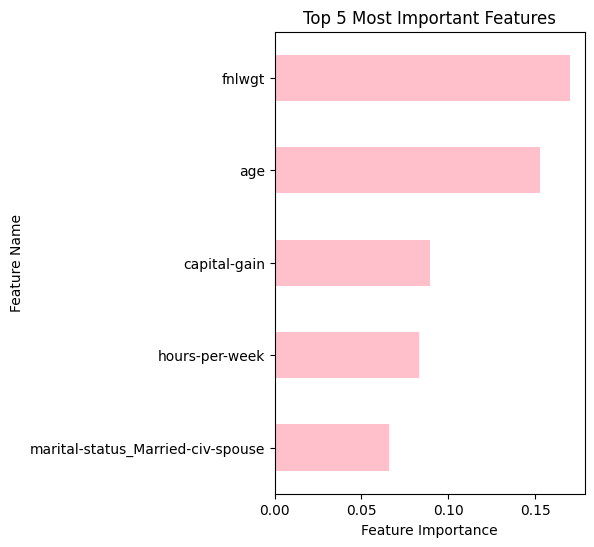

In [17]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.Series(rf_clf.feature_importances_, index=feature_names,
                        name='Feature Importances')

ax = feature_importance.sort_values().tail(5).plot(kind='barh',figsize=(4,6),color='pink')
ax.set(ylabel='Feature Name',xlabel='Feature Importance',
       title='Top 5 Most Important Features');

## permutation importance

In [18]:
preprocessor.fit(X_train)
feature_names = preprocessor.get_feature_names_out()


X_train_tf = pd.DataFrame(preprocessor.transform(X_train),
                          columns = feature_names, index = X_train.index)

X_test_tf = pd.DataFrame(preprocessor.transform(X_test),
                          columns = feature_names, index = X_test.index)
X_test_tf.head(3)

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
7762,1.266263,-1.484991,-0.418689,-0.144456,-0.219726,-0.03437,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
23881,-0.992617,-0.728546,-0.418689,-0.144456,-0.219726,-0.03437,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
30507,0.318991,-0.181335,1.136723,1.785937,-0.219726,-0.03437,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [19]:

print(X_train_tf.shape)
print(X_test_tf.shape)


(39073, 108)
(9769, 108)


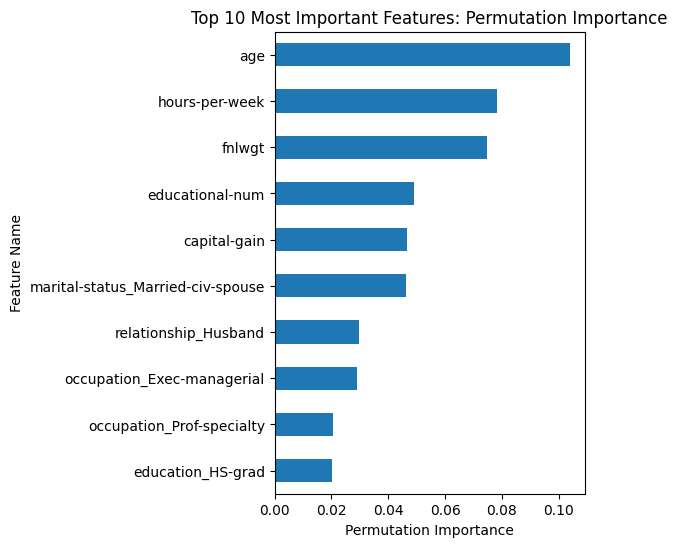

In [20]:
from sklearn.inspection import permutation_importance

SEED = 321
np.random.seed(SEED)
r = permutation_importance(rf_clf, X_train_tf, y_train ,n_repeats =5, random_state = SEED)
## can make the mean importances into a series
perm_importances = pd.Series(r['importances_mean'],index=X_train_tf.columns,
                           name = 'permutation importance')
ax = perm_importances.sort_values().tail(10).plot(kind='barh',figsize=(4,6))
ax.set(ylabel='Feature Name',xlabel='Permutation Importance',
       title='Top 10 Most Important Features: Permutation Importance');


Based on domain knowledge, I anticipate that **age** and **weekly working hours** are the most influential features.


## Top 2 

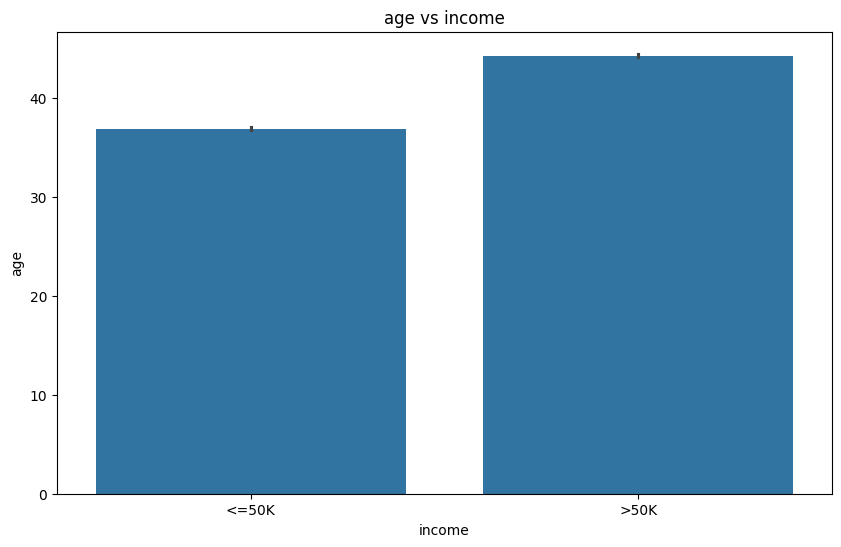

In [21]:
fig,ax=plt.subplots(figsize=(10,6))
sns.barplot(data=df , x='income',y='age')
ax.set_title('age vs income')
ax.set_xlabel('income')
ax.set_ylabel('age');

“The bar plot indicates that the >50K income group has a higher average age than the <=50K group. This suggests that age may be positively related to income in this dataset, possibly because older individuals have more work experience and career progression.”



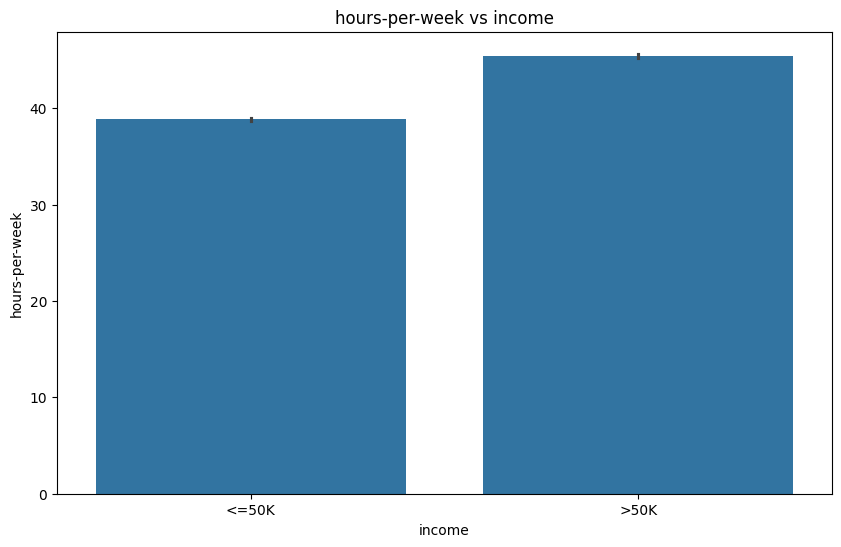

In [22]:
fig,ax=plt.subplots(figsize=(10,6))
sns.barplot(data=df , x='income',y='hours-per-week')
ax.set_title('hours-per-week vs income')
ax.set_xlabel('income')
ax.set_ylabel('hours-per-week');

“The hours-per-week vs income plot shows that the >50K group has a higher average number of working hours per week than the <=50K group. This suggests that longer working hours may be associated with higher income in this dataset.”


# PCA

In [23]:
y_train.value_counts()

income
<=50K    29676
>50K      9397
Name: count, dtype: int64

## Handle Imbalanced classes

In [24]:
from imblearn.over_sampling import SMOTE as smote
smote=smote(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(X_train_tf,y_train)

print(X_train_smote.shape)
print(X_test_tf.shape)

(59352, 108)
(9769, 108)


In [25]:
# import pca
from sklearn.decomposition import PCA
pca=PCA(n_components=3)
x_train_pca=pca.fit_transform(X_train_smote)
x_test_pca=pca.transform(X_test_tf) 

# Model with PCA

In [26]:
import datetime
start2 = datetime.datetime.now()


# import knn
from sklearn.neighbors import KNeighborsClassifier
rf_clf = RandomForestClassifier(random_state = 42)
rf_clf.fit(x_train_pca,y_train_smote)

end2 = datetime.datetime.now()
time2=end2 -start2
print(time2)

# import confusion matrix
from sklearn.metrics import confusion_matrix
y_pred=rf_clf.predict(x_test_pca)
cr=classification_report(y_test,y_pred)
print(cr)

0:00:12.330770
              precision    recall  f1-score   support

       <=50K       0.93      0.79      0.85      7479
        >50K       0.53      0.79      0.64      2290

    accuracy                           0.79      9769
   macro avg       0.73      0.79      0.75      9769
weighted avg       0.83      0.79      0.80      9769



# Clustering

In [27]:
from sklearn.cluster import KMeans # K-means algorithm
from sklearn.metrics import silhouette_score

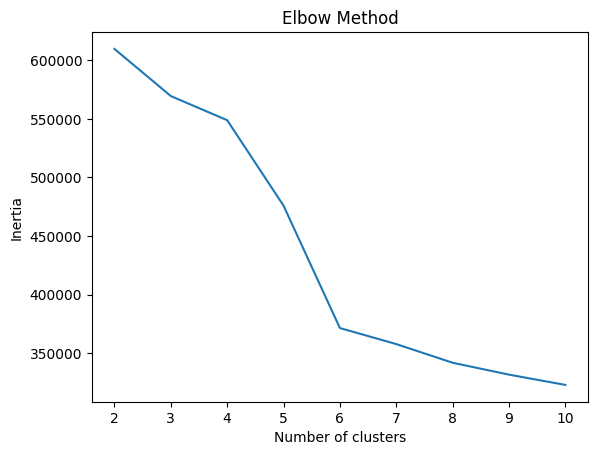

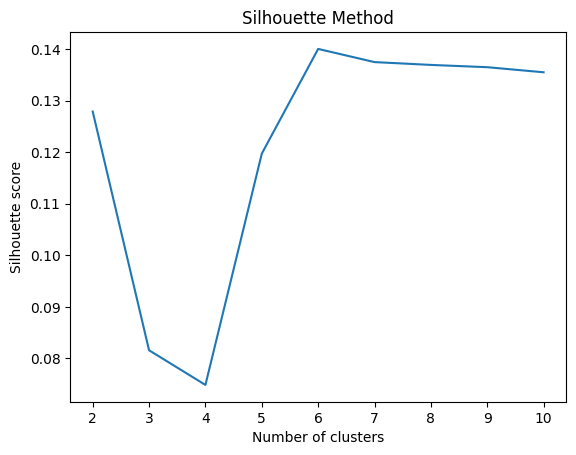

In [28]:
ks = range(2, 11)

inertias = []
sils = []

for k in ks:
  model = KMeans(n_clusters=k)
  model.fit(X_train_smote)
  inertias.append(model.inertia_)
  sils.append(silhouette_score(X_train_smote, model.labels_))

plt.plot(ks, inertias)
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')

plt.show()

plt.plot(ks, sils)
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.title('Silhouette Method')

plt.show()

In [29]:
print(X_train_smote.shape)
print(X_test_tf.shape)

(59352, 108)
(9769, 108)


In [30]:

# Refit KMeans with 2 clusters
kmeans = KMeans(n_clusters=2, n_init= 'auto', random_state=42)
kmeans.fit(X_train_smote)
# Add the clusters as a column in the dataframe
X_train_smote['cluster'] = kmeans.labels_
X_train_smote.head()


X_test_tf['cluster'] = kmeans.predict(X_test_tf)
X_test_tf.head()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,workclass_?,workclass_Federal-gov,workclass_Local-gov,workclass_Never-worked,...,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia,cluster
7762,1.266263,-1.484991,-0.418689,-0.144456,-0.219726,-0.034370,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
23881,-0.992617,-0.728546,-0.418689,-0.144456,-0.219726,-0.034370,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
30507,0.318991,-0.181335,1.136723,1.785937,-0.219726,-0.034370,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
28911,-0.482548,-0.027042,-0.418689,-0.144456,-0.219726,-0.034370,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0
19484,0.027522,0.837237,1.136723,-0.144456,-0.219726,-0.837085,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1


# Feature Engineering

In [31]:
X_train_smote['total_capital'] = X_train_smote['capital-gain'] + X_train_smote['capital-loss']
X_test_tf['total_capital'] = X_test_tf['capital-gain'] + X_test_tf['capital-loss']

In [32]:
print(X_train_smote.shape)
print(X_test_tf.shape)

(59352, 110)
(9769, 110)


## Model with feature engineering

In [33]:
import datetime
start2 = datetime.datetime.now()


# import knn
from sklearn.neighbors import KNeighborsClassifier
rf_clf = RandomForestClassifier(random_state = 42)
rf_clf.fit(X_train_smote,y_train_smote)

end2 = datetime.datetime.now()
time2=end2 -start2
print(time2)

# import confusion matrix
from sklearn.metrics import confusion_matrix
y_pred=rf_clf.predict(X_test_tf)
cr=classification_report(y_test,y_pred)
print(cr)

0:00:10.647443
              precision    recall  f1-score   support

       <=50K       0.91      0.89      0.90      7479
        >50K       0.67      0.71      0.69      2290

    accuracy                           0.85      9769
   macro avg       0.79      0.80      0.80      9769
weighted avg       0.85      0.85      0.85      9769



# Feature selection

In [34]:
start3 = datetime.datetime.now()
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

rfe_model = RandomForestClassifier(n_estimators=100, random_state=42)

rfe = RFE(rfe_model, n_features_to_select=50)
rfe.fit(X_train_smote, y_train_smote)

selected_features_rfe = X_train_smote.columns[rfe.support_]

print("RFE Selected Features:\n", selected_features_rfe)
end3 = datetime.datetime.now()
time3=end3 -start3
print(time3)



RFE Selected Features:
 Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week', 'workclass_Federal-gov', 'workclass_Local-gov',
       'workclass_Private', 'workclass_Self-emp-inc',
       'workclass_Self-emp-not-inc', 'workclass_State-gov',
       'education_Assoc-acdm', 'education_Assoc-voc', 'education_Bachelors',
       'education_HS-grad', 'education_Masters', 'education_Some-college',
       'marital-status_Divorced', 'marital-status_Married-civ-spouse',
       'marital-status_Never-married', 'marital-status_Separated',
       'occupation_?', 'occupation_Adm-clerical', 'occupation_Craft-repair',
       'occupation_Exec-managerial', 'occupation_Farming-fishing',
       'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct',
       'occupation_Other-service', 'occupation_Prof-specialty',
       'occupation_Protective-serv', 'occupation_Sales',
       'occupation_Tech-support', 'occupation_Transport-moving',
       'relationship_Hu

##  Model with feature engineering and Wrapper Method

In [39]:
# Transform training and testing sets
X_train_rfe = rfe.transform(X_train_smote)
X_test_rfe = rfe.transform(X_test_tf)

final_model_rfe = RandomForestClassifier(n_estimators=100, random_state=42)

final_model_rfe.fit(X_train_rfe, y_train_smote)

y_pred_rfe = final_model_rfe.predict(X_test_rfe)

In [40]:
from sklearn.metrics import accuracy_score, classification_report

print("RFE Model Accuracy:", accuracy_score(y_test, y_pred_rfe))
print(classification_report(y_test, y_pred_rfe))


RFE Model Accuracy: 0.8506500153546934
              precision    recall  f1-score   support

       <=50K       0.91      0.89      0.90      7479
        >50K       0.67      0.72      0.69      2290

    accuracy                           0.85      9769
   macro avg       0.79      0.80      0.80      9769
weighted avg       0.85      0.85      0.85      9769



RFE increases training time because it:

- Trains the model multiple times
- Iteratively removes features



Despite the extra time, the performance:

- Did not improve significantly
- Only showed a very small gain in recall

# top 10  permutation_importance features

In [43]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

result = permutation_importance(
    final_model_rfe,
    X_train_rfe,
    y_train_smote,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": selected_features_rfe,
    "Importance": result.importances_mean
}).sort_values(by="Importance", ascending=False)

top10 = importance_df.head(10)

print(top10)

                              Feature  Importance
0                                 age    0.126698
5                      hours-per-week    0.099129
1                              fnlwgt    0.066827
2                     educational-num    0.033010
35               relationship_Husband    0.032779
48                            cluster    0.024491
25         occupation_Exec-managerial    0.024478
19  marital-status_Married-civ-spouse    0.021467
3                        capital-gain    0.019806
49                      total_capital    0.015715


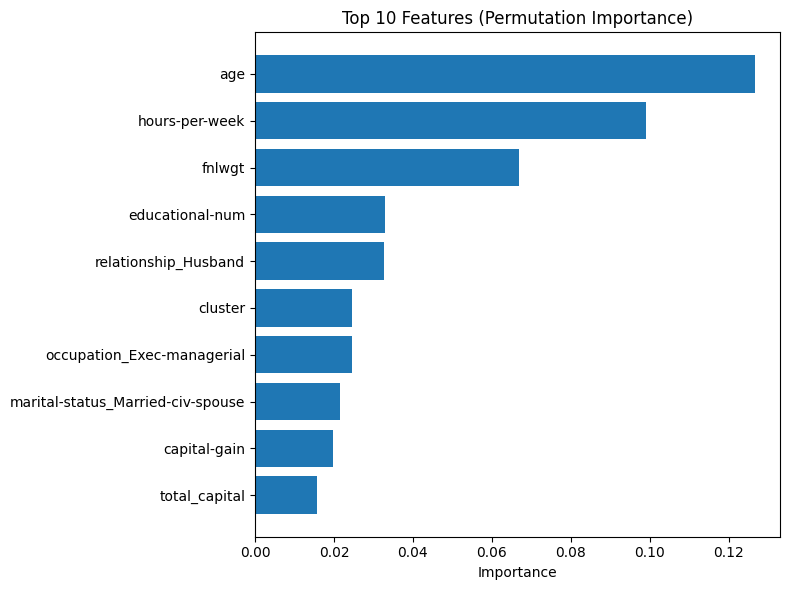

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.barh(top10["Feature"], top10["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Features (Permutation Importance)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

Some new features appeared in this model, such as cluster and total capital, which were not present among the top features in previous models.
